# Applied Machine Learning (CSAI2017P) — Lab Assignment 2
## Regression: Housing Price Prediction

Experiments 3 · CO2, CO4 · **10 marks**

| | |
|---|---|
| Name | Anirudh Awasthi |
| SAP ID | 590027460 |
| Batch |Batch-5|
| Due | announced in the lab |
| Lab quiz | LQ2, after submission |

**Datasets:** A1 (California Housing)

---

### Before you start
- Attempt **2 of 3** in Section A, **1 of 2** in Section B. Section C is compulsory.
- Fit every transformer inside a `Pipeline`. Never fit on the test set.
- Set `random_state` wherever the question asks for reproducibility.
- Every question wants a short written observation, not just a number.
- Restart the kernel and run top-to-bottom before you submit.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

for m in (np, pd, sklearn):
    print(f"{m.__name__:12s} {m.__version__}")


numpy        2.4.3
pandas       2.3.3
sklearn      1.8.0


## Load the data

Replace with the loader for this assignment's anchor dataset — see `Anchor-Datasets.pdf` for the snippets.

In [2]:
from sklearn.datasets import fetch_california_housing

d = fetch_california_housing(as_frame=True)
df = d.frame


---

# Section A — attempt any 2 of 3 (2 marks each)

*attempt 2 of 3*

## A1. Simple linear regression  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1. Target: `MedHouseVal`.*

a. Fit a regression of `MedHouseVal` on `MedInc` alone.
b. Report the slope, the intercept and test R^2.
c. State in one sentence what the slope means in real units.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[["MedInc"]]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("Test R²:", r2_score(y_test, y_pred))

Slope: 0.4203217769894005
Intercept: 0.4432063522765708
Test R²: 0.4466846804895943


**Observation (A1):**
The model shows a positive relationship between MedInc and MedHouseVal, with a slope of 0.42, meaning a 1-unit increase in income is associated with about a $42,000 increase in predicted house value. The test R² of 0.44 shows that income alone explains around 44% of the variation, so other factors also matter.

## A2. Multiple linear regression  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1, all features.*

a. Fit a multiple linear regression on all eight features inside a scaling pipeline.
b. Report test MAE, RMSE and R^2.
c. Plot predicted against actual and describe the pattern in two lines.


Test MAE: 0.5351261336554507
Test RMSE: 0.7273129773603114
Test R²: 0.5943232652466204


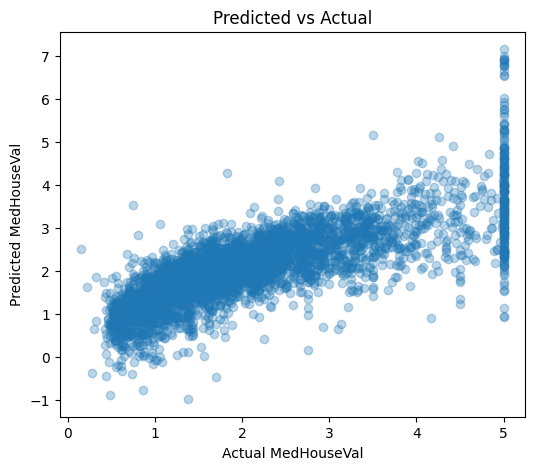

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R²:", r2)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Predicted vs Actual")
plt.show()

**Observation (A2):**
The predictions generally increase with the actual house values, showing a clear positive relationship. However, the points are fairly scattered from a perfect diagonal pattern, especially for higher-valued houses, indicating noticeable prediction errors.

## A3. Metric choice  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1.*

a. Compute MAE, MSE and RMSE for your model from A2.
b. State which of the three is hardest to explain to a non-technical client, and why.
c. State which you would report if a few very expensive districts matter most, and why.


**Observation (A3):**

> *write 2–6 lines here*

---

# Section B — attempt any 1 of 2 (4 marks each)

*attempt 1 of 2*

## B1. Polynomial features and over-fitting  &nbsp;&nbsp;`[4 marks]`

*Dataset: A1.*

a. Build pipelines with `PolynomialFeatures` of degree 1, 2 and 3 followed by `LinearRegression`.
b. Report train and test RMSE for each degree in one table.
c. Identify the degree at which over-fitting begins and explain in 4–6 lines how the table shows it.


In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

results = []

for degree in [1, 2, 3]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("regressor", LinearRegression())
    ])
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    results.append([degree, train_rmse, test_rmse])

results_df = pd.DataFrame(
    results,
    columns=["Degree", "Train RMSE", "Test RMSE"]
)

print(results_df)

   Degree  Train RMSE   Test RMSE
0       1    0.723492    0.727313
1       2    0.647843    1.662482
2       3    0.600468  228.143584


**Observation (B1):**
Overfitting starts at degree 2, where train RMSE decreases from 0.723 to 0.648 but test RMSE increases from 0.727 to 1.662. At degree 3, this gap becomes extreme, with test RMSE reaching 228.14 while train RMSE falls to 0.60, showing that the model is fitting the training data too closely and failing to generalize.

## B2. Ridge and Lasso  &nbsp;&nbsp;`[4 marks]`

*Dataset: A1 with degree-2 polynomial features.*

a. Fit Ridge and Lasso for α ∈ {0.01, 0.1, 1, 10, 100} and plot test RMSE against α.
b. Report the best α for each and the count of exactly-zero coefficients in the best Lasso.
c. Explain in 4–6 lines why Lasso zeroes coefficients and Ridge does not.


In [6]:
# B2 — code


**Observation (B2):**

> *write 2–6 lines here*

---

# Section C — compulsory (2 marks)

*compulsory*

## C1. Where the model fails  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1.*

a. Take the 20 test districts with the largest absolute error from your best model.
b. Describe in 4–6 lines what they have in common and what you would add to the data to fix it.


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Best model: multiple linear regression from A2
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

# Absolute error
errors = np.abs(y_test - pred)

# Top 20 largest errors
top20 = X_test.copy()
top20["Actual"] = y_test
top20["Predicted"] = pred
top20["Absolute Error"] = errors

top20 = top20.sort_values(
    "Absolute Error", ascending=False
).head(20)

print(top20)

       MedInc  HouseAge  AveRooms  AveBedrms  Population   AveOccup  Latitude  \
12138  2.6250      16.0  4.000000   0.500000        39.0   2.785714     33.87   
4861   0.4999      29.0  2.373272   1.055300      2690.0  12.396313     34.02   
10574  1.9659       6.0  4.795455   1.159091       125.0   2.840909     33.72   
16642  0.7025      19.0  2.425197   1.125984      1799.0   2.833071     35.30   
6651   1.9923      41.0  3.279373   1.062663       855.0   2.232376     34.15   
4630   2.3674      20.0  2.740554   1.047859      2919.0   2.450882     34.07   
4623   0.8804      36.0  2.713235   1.080882       145.0   1.066176     34.06   
13360  2.1250       6.0  5.904762   1.119048       119.0   2.833333     34.02   
15615  1.8981      31.0  3.323064   1.091590      2305.0   1.919234     37.81   
9168   1.9667       2.0  5.715976   1.597633       233.0   1.378698     34.42   
8859   2.9107      22.0  4.173077   1.140385       850.0   1.634615     34.07   
17306  2.7275      17.0  5.5

**Observation (C1):**
Many of the largest errors occur for districts whose actual MedHouseVal is at the upper limit of 5.0, while the model predicts much lower values. This suggests that the target cap makes these high-value districts difficult to model accurately. I would add more detailed property-level and location-based features, along with uncapped house values, to better capture expensive districts.

---

## Self-check before submitting

- [ ] Kernel restarted and run top-to-bottom, all outputs visible
- [ ] Every attempted question has a written observation
- [ ] No transformer fitted outside a pipeline
- [ ] Metrics reported with units where they have any
- [ ] File named `AML_LA02_<SAPID>.ipynb`
